In [2]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df[['Sales','Profit','Discount','Category','Sub-Category','Region']].head()


,Sales,Profit,Discount,Category,Sub-Category,Region
0,261.9600,41.9136,0.00,Furniture,Bookcases,South
1,731.9400,219.5820,0.00,Furniture,Chairs,South
2,14.6200,6.8714,0.00,Office Supplies,Labels,West
3,957.5775,-383.0310,0.45,Furniture,Tables,South
4,22.3680,2.5164,0.20,Office Supplies,Storage,South


In [ ]:
# Date column ko date format me convert karo
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year


In [ ]:
# Q1. Top five products / categories contributing most to profit
# Kaunsi category overall profit de rahi hai
# Kaunsi category me loss ho raha hai
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(cat_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [7]:
# Product wise top 5 profit
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(5)
print(top_products)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64


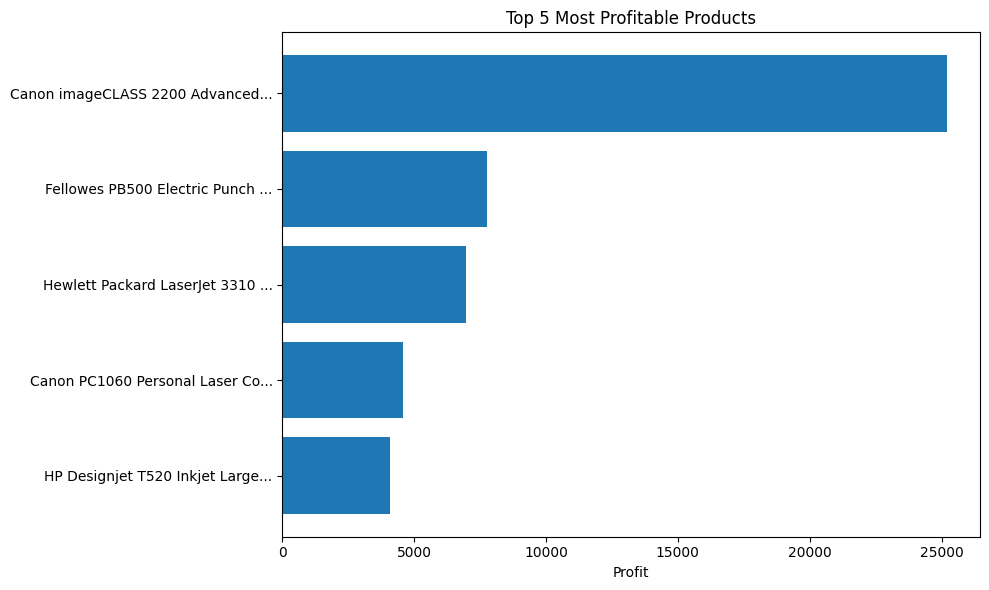

In [10]:
import matplotlib.pyplot as plt

top5 = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

short_names = [name[:30] + '...' for name in top5.index]

plt.figure(figsize=(10,6))
plt.barh(short_names, top5.values)
plt.xlabel('Profit')
plt.title('Top 5 Most Profitable Products')
plt.gca().invert_yaxis()  # highest profit upar dikhe
plt.tight_layout()
plt.show()

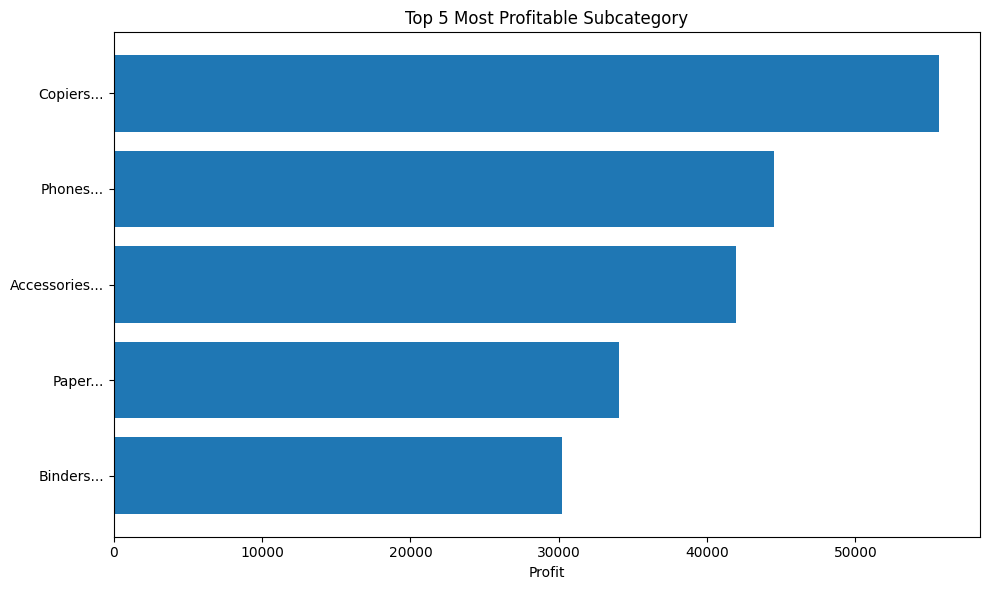

In [42]:
import matplotlib.pyplot as plt

top5 = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

short_names = [name[:30] + '...' for name in top5.index]

plt.figure(figsize=(10,6))
plt.barh(short_names, top5.values)
plt.xlabel('Profit')
plt.title('Top 5 Most Profitable Subcategory')
plt.gca().invert_yaxis()  # highest profit upar dikhe
plt.tight_layout()
plt.show()

In [6]:
# Kis category me zyada discount diya ja raha hai
df.groupby('Category')['Discount'].mean().sort_values(ascending=False)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

In [8]:
summary = (
    df.groupby(['Category','Sub-Category'])
      .agg({
          'Sales': 'sum',
          'Profit': 'sum',
          'Discount': 'mean'
      })
      .sort_values(by='Profit', ascending=False)
)

summary


Sales      Profit  Discount
Category        Sub-Category                                   
Technology      Copiers       149528.0300  55617.8249  0.161765
                Phones        330007.0540  44515.7306  0.154556
                Accessories   167380.3180  41936.6357  0.078452
Office Supplies Paper          78479.2060  34053.5693  0.074891
                Binders       203412.7330  30221.7633  0.372292
Furniture       Chairs        328449.1030  26590.1663  0.170178
Office Supplies Storage       223843.6080  21278.8264  0.074704
                Appliances    107532.1610  18138.0054  0.166524
Furniture       Furnishings    91705.1640  13059.1436  0.138349
Office Supplies Envelopes      16476.4020   6964.1767  0.080315
                Art            27118.7920   6527.7870  0.074874
                Labels         12486.3120   5546.2540  0.068681
Technology      Machines      189238.6310   3384.7569  0.306087
Office Supplies Fasteners       3024.2800    949.5182  0.082028
                Supplies       46673.5380  -1189.0995  0.076842
Furniture       Bookcases     114879.9963  -3472.5560  0.211140
                Tables        206965.5320 -17725.4811  0.261285

In [5]:
# Kaunsa sub-category overall profit de raha hai
df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values(by='Profit', ascending=False)


,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


In [ ]:
# Q2: Highlight products or segments generating high sales but low or negative profit
# Aise products/segments jinki sales high hai par profit low ya negative hai
# Step 2.1 — Category wise Sales aur Profit nikaalo
subcat_perf = df.groupby('Sub-Category')[['Sales','Profit','Discount']].sum()
subcat_perf = subcat_perf.sort_values(by='Sales', ascending=False)

subcat_perf.head(10)



,Sales,Profit,Discount
Sub-Category,,,
Phones,330007.0540,44515.7306,137.40
Chairs,328449.1030,26590.1663,105.00
Storage,223843.6080,21278.8264,63.20
Tables,206965.5320,-17725.4811,83.35
Binders,203412.7330,30221.7633,567.00
Machines,189238.6310,3384.7569,35.20
Accessories,167380.3180,41936.6357,60.80
Copiers,149528.0300,55617.8249,11.00
Bookcases,114879.9963,-3472.5560,48.14


In [16]:
# Step 2.2 — Filter karo: Sales high, Profit negative
loss_subcat = subcat_perf[(subcat_perf['Sales'] > 20000) & (subcat_perf['Profit'] < 0)]
loss_subcat.sort_values(by='Sales', ascending=False)



,Sales,Profit,Discount
Sub-Category,,,
Tables,206965.5320,-17725.4811,83.35
Bookcases,114879.9963,-3472.5560,48.14
Supplies,46673.5380,-1189.0995,14.60


In [17]:
# 🔹 Step 2.3 — Check karo discount kitna diya ja raha hai
loss_subcat[['Sales','Profit','Discount']].head(10)


,Sales,Profit,Discount
Sub-Category,,,
Tables,206965.5320,-17725.4811,83.35
Bookcases,114879.9963,-3472.5560,48.14
Supplies,46673.5380,-1189.0995,14.60


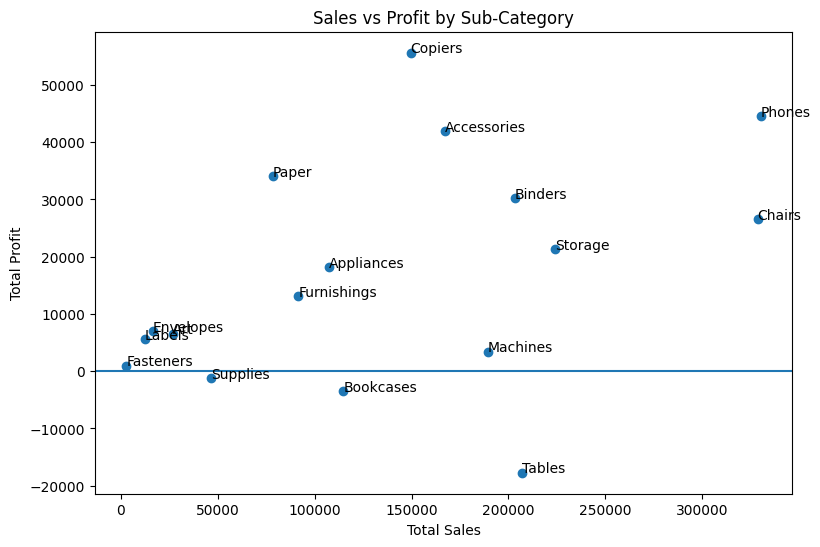

In [21]:
subcat = df.groupby('Sub-Category')[['Sales','Profit']].sum().reset_index()
plt.figure(figsize=(9,6))

plt.scatter(subcat['Sales'], subcat['Profit'])

for i in range(len(subcat)):
    plt.text(subcat['Sales'][i], subcat['Profit'][i], subcat['Sub-Category'][i])

plt.axhline(0)  # profit zero line
plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.title('Sales vs Profit by Sub-Category')
plt.show()


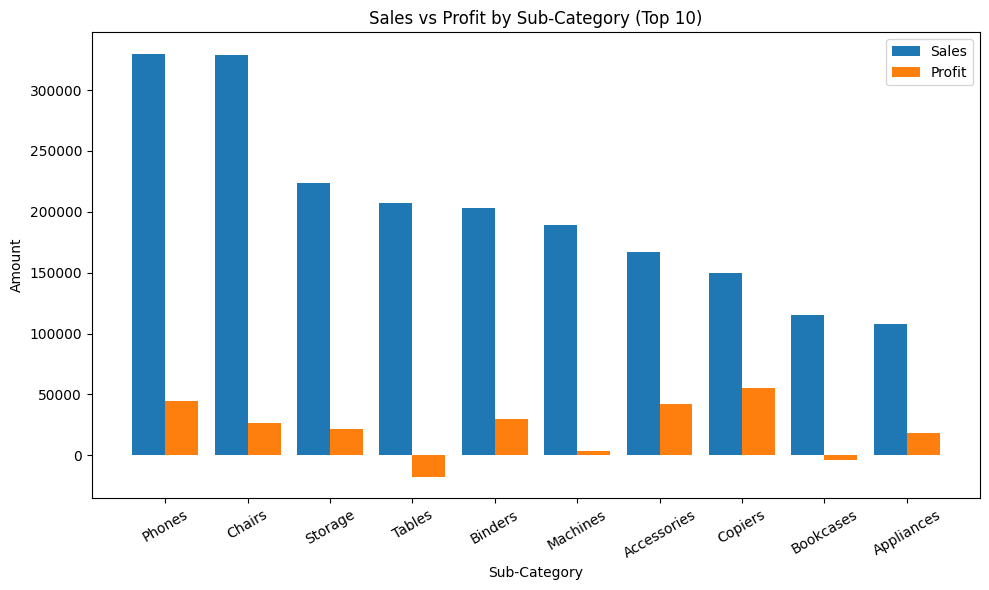

In [23]:
import matplotlib.pyplot as plt

subcat = df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False).head(10)

plt.figure(figsize=(10,6))

x = range(len(subcat))

plt.bar(x, subcat['Sales'], width=0.4, label='Sales')
plt.bar([i + 0.4 for i in x], subcat['Profit'], width=0.4, label='Profit')

plt.xticks([i + 0.2 for i in x], subcat.index, rotation=30)
plt.xlabel('Sub-Category')
plt.ylabel('Amount')
plt.title('Sales vs Profit by Sub-Category (Top 10)')
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# Q3: Determine the best-performing region and explain the factors contributing to its success.
# Kis region me company sabse zyada profit kama rahi hai — aur kyun?
# Step 3.1 — Region wise Sales, Profit, Discount
region_perf = df.groupby('Region')[['Sales','Profit','Discount']].sum().sort_values(by='Profit', ascending=False)
region_perf


,Sales,Profit,Discount
Region,,,
West,725457.8245,108418.4489,350.20
East,678781.2400,91522.7800,414.00
South,391721.9050,46749.4303,238.55
Central,501239.8908,39706.3625,558.34


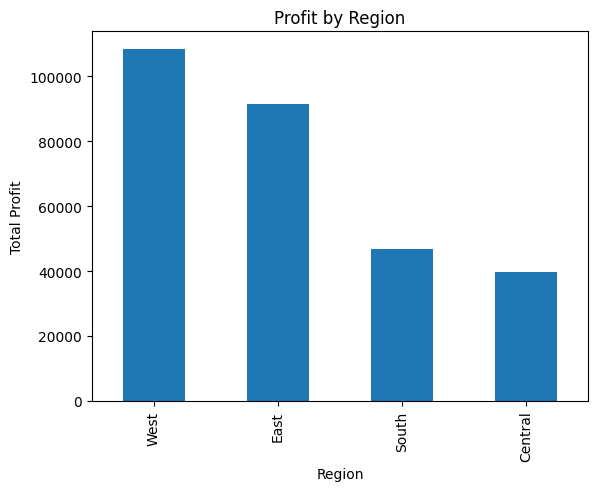

In [25]:
# Step 3.2 — Simple bar graph (Profit by Region)
import matplotlib.pyplot as plt

region_perf['Profit'].plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()


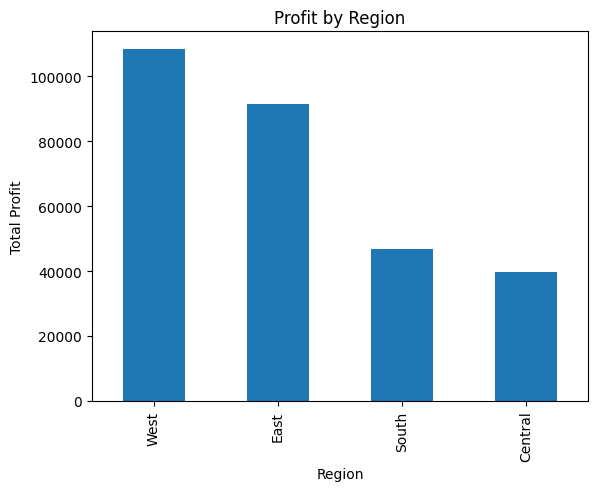

In [27]:
# Q4: Identify underperforming regions and recommend corrective strategies.
# Kis region me problem ho rahi hai
# Aur company ko kya action lena chahiye
# Central (most cases me) → Sales theek, Profit low/negative, Discount high
region_perf['Profit'].plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()


In [30]:
central_data = df[df['Region'] == 'Central']

central_subcat = central_data.groupby('Sub-Category')[['Sales','Profit','Discount']].sum().sort_values(by='Profit')
central_subcat.head(10)
top_loss = central_subcat.head(8)


C:\Users\shwet\AppData\Local\Temp\ipykernel_17908\2474940451.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_loss['Loss'] = top_loss['Profit'].abs()


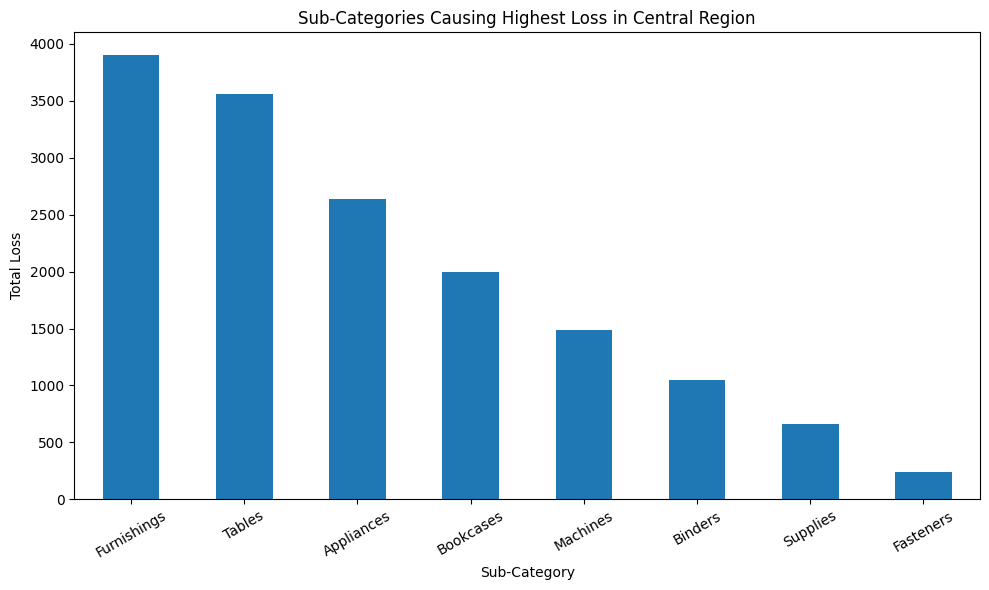

In [32]:
top_loss['Loss'] = top_loss['Profit'].abs()
top_loss = top_loss.sort_values(by='Loss', ascending=False)
plt.figure(figsize=(10,6))

top_loss['Loss'].plot(kind='bar')

plt.title('Sub-Categories Causing Highest Loss in Central Region')
plt.xlabel('Sub-Category')
plt.ylabel('Total Loss')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [33]:
# Q5: Sales Trend (Season / Time Pattern)
# Kis month me sales zyada hoti hai, kis month me kam
# Taaki company inventory planning sahi kar sake.
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
# Month wise total sales
month_sales = df.groupby('Month_Name')['Sales'].sum()
month_sales


Month_Name
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [34]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_sales = month_sales.reindex(month_order)


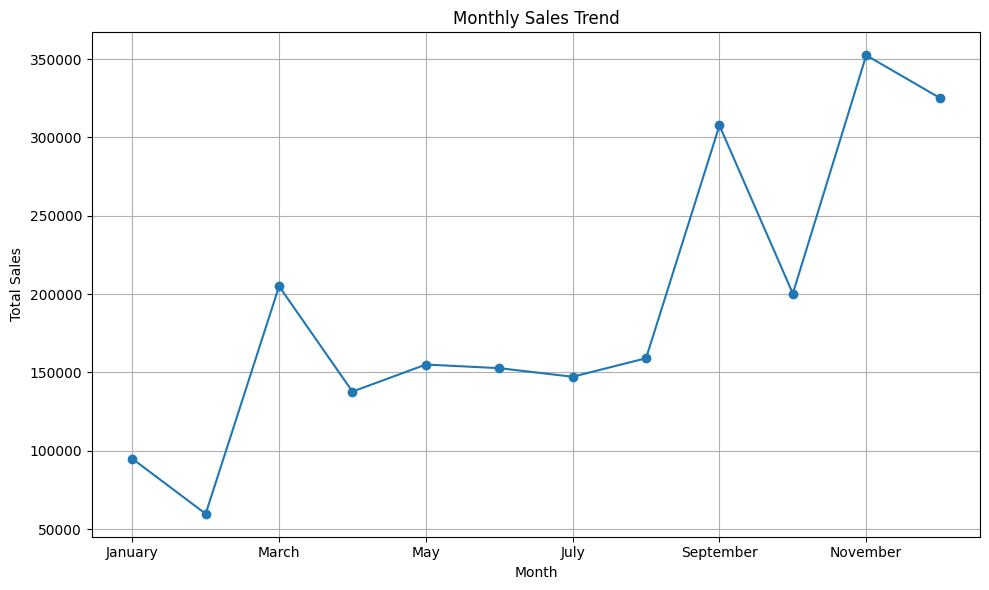

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

month_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
# Profit Margin %
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100
subcat_margin = df.groupby('Sub-Category')[['Sales','Profit']].sum()
subcat_margin['Profit_Margin'] = (subcat_margin['Profit'] / subcat_margin['Sales']) * 100
subcat_margin.sort_values(by='Profit_Margin', ascending=False)


NameError: name 'df' is not defined

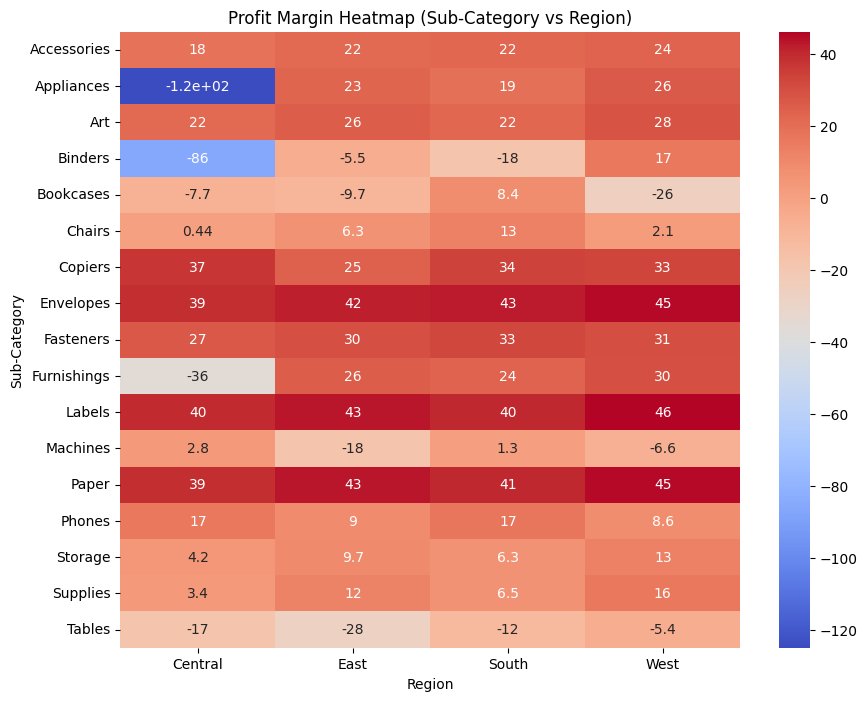

In [ ]:
# Profit Margin Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.pivot_table(values='Profit_Margin',
                       index='Sub-Category',
                       columns='Region',
                       aggfunc='mean')

plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Profit Margin Heatmap (Sub-Category vs Region)')
plt.show()


In [ ]:
# Proper Quadrant Identification
subcat = df.groupby('Sub-Category')[['Sales','Profit']].sum().reset_index()

high_sales = subcat['Sales'].mean()
low_profit = subcat['Profit'].mean()

problem_items = subcat[(subcat['Sales'] > high_sales) & (subcat['Profit'] < low_profit)]
problem_items


,Sub-Category,Sales,Profit
11,Machines,189238.631,3384.7569
16,Tables,206965.532,-17725.4811


In [40]:
# Average Order Value by Region
aov = df.groupby('Region').apply(lambda x: x['Sales'].sum() / x.shape[0])
aov


C:\Users\shwet\AppData\Local\Temp\ipykernel_17908\491828925.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aov = df.groupby('Region').apply(lambda x: x['Sales'].sum() / x.shape[0])


Region
Central    215.772661
East       238.336110
South      241.803645
West       226.493233
dtype: float64

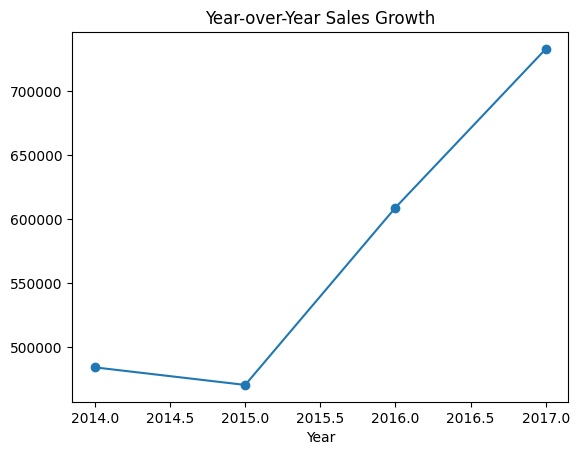

In [41]:
# Year-over-Year Growth
year_sales = df.groupby('Year')['Sales'].sum()
year_sales.plot(marker='o')
plt.title('Year-over-Year Sales Growth')
plt.show()


In [ ]:
# Region wise average discount
discount_region = df.groupby('Region')['Discount'].mean().sort_values(ascending=False)
discount_region
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

discount_region.plot(kind='bar')

plt.title('Average Discount by Region')
plt.xlabel('Region')
plt.ylabel('Average Discount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()